In [9]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer

In [10]:
df=pd.read_csv('/content/reviews_data.csv')
df

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...
...,...,...,...,...,...,...
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,I ordered two venti frappacino's without whipp...,['No Images']
846,Bob,"Goodrich, MI","Reviewed Jan. 3, 2005",NaN,No Review Text,['No Images']
847,Erik,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,Andrew,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']


In [11]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
df=df.drop(columns=['Date','Rating','Image_Links'])
df

,name,location,Review
0,Helen,"Wichita Falls, TX",Amber and LaDonna at the Starbucks on Southwes...
1,Courtney,"Apopka, FL",** at the Starbucks by the fire station on 436...
2,Daynelle,"Cranberry Twp, PA",I just wanted to go out of my way to recognize...
3,Taylor,"Seattle, WA",Me and my friend were at Starbucks and my card...
4,Tenessa,"Gresham, OR",I’m on this kick of drinking 5 cups of warm wa...
...,...,...,...
845,Becky,"Agoura Hills, CA",I ordered two venti frappacino's without whipp...
846,Bob,"Goodrich, MI",No Review Text
847,Erik,"Valley Village, CA","DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL..."
848,Andrew,"Fallbrook, CA",No Review Text


In [13]:
df['Review_lower'] = df['Review'].str.lower()
display(df[['Review', 'Review_lower']].head())

,Review,Review_lower
0,Amber and LaDonna at the Starbucks on Southwes...,amber and ladonna at the starbucks on southwes...
1,** at the Starbucks by the fire station on 436...,** at the starbucks by the fire station on 436...
2,I just wanted to go out of my way to recognize...,i just wanted to go out of my way to recognize...
3,Me and my friend were at Starbucks and my card...,me and my friend were at starbucks and my card...
4,I’m on this kick of drinking 5 cups of warm wa...,i’m on this kick of drinking 5 cups of warm wa...


In [14]:
df['Review_tokens'] = df['Review_lower'].apply(word_tokenize)
display(df[['Review_lower', 'Review_tokens']].head())

,Review_lower,Review_tokens
0,amber and ladonna at the starbucks on southwes...,"[amber, and, ladonna, at, the, starbucks, on, ..."
1,** at the starbucks by the fire station on 436...,"[*, *, at, the, starbucks, by, the, fire, stat..."
2,i just wanted to go out of my way to recognize...,"[i, just, wanted, to, go, out, of, my, way, to..."
3,me and my friend were at starbucks and my card...,"[me, and, my, friend, were, at, starbucks, and..."
4,i’m on this kick of drinking 5 cups of warm wa...,"[i, ’, m, on, this, kick, of, drinking, 5, cup..."


In [15]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['Review_no_stopwords'] = df['Review_tokens'].apply(remove_stopwords)
display(df[['Review_tokens', 'Review_no_stopwords']].head())

,Review_tokens,Review_no_stopwords
0,"[amber, and, ladonna, at, the, starbucks, on, ...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[*, *, at, the, starbucks, by, the, fire, stat...","[*, *, starbucks, fire, station, 436, altamont..."
2,"[i, just, wanted, to, go, out, of, my, way, to...","[wanted, go, way, recognize, starbucks, employ..."
3,"[me, and, my, friend, were, at, starbucks, and...","[friend, starbucks, card, ’, work, ., thankful..."
4,"[i, ’, m, on, this, kick, of, drinking, 5, cup...","[’, kick, drinking, 5, cups, warm, water, ., w..."


In [16]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['Review_stemmed'] = df['Review_no_stopwords'].apply(apply_stemming)
display(df[['Review_no_stopwords', 'Review_stemmed']].head(10))

,Review_no_stopwords,Review_stemmed
0,"[amber, ladonna, starbucks, southwest, parkway...","[amber, ladonna, starbuck, southwest, parkway,..."
1,"[*, *, starbucks, fire, station, 436, altamont...","[*, *, starbuck, fire, station, 436, altamont,..."
2,"[wanted, go, way, recognize, starbucks, employ...","[want, go, way, recogn, starbuck, employe, bil..."
3,"[friend, starbucks, card, ’, work, ., thankful...","[friend, starbuck, card, ’, work, ., thank, wo..."
4,"[’, kick, drinking, 5, cups, warm, water, ., w...","[’, kick, drink, 5, cup, warm, water, ., work,..."
5,"[correct, order, 3, times, ., never, got, righ...","[correct, order, 3, time, ., never, got, right..."
6,"[tried, starbucks, several, different, times, ...","[tri, starbuck, sever, differ, time, differ, l..."
7,"[starbucks, near, launched, new, fall, foods, ...","[starbuck, near, launch, new, fall, food, beve..."
8,"[ordered, online, reisterstown, rd, ,, st, tho...","[order, onlin, reisterstown, rd, ,, st, thoma,..."
9,"[staff, smythe, st., superstore, location, fre...","[staff, smyth, st., superstor, locat, frederic..."


In [17]:
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['Review_lemmatized'] = df['Review_no_stopwords'].apply(apply_lemmatization)
display(df[['Review_stemmed', 'Review_lemmatized']].head(10))

,Review_stemmed,Review_lemmatized
0,"[amber, ladonna, starbuck, southwest, parkway,...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[*, *, starbuck, fire, station, 436, altamont,...","[*, *, starbucks, fire, station, 436, altamont..."
2,"[want, go, way, recogn, starbuck, employe, bil...","[wanted, go, way, recognize, starbucks, employ..."
3,"[friend, starbuck, card, ’, work, ., thank, wo...","[friend, starbucks, card, ’, work, ., thankful..."
4,"[’, kick, drink, 5, cup, warm, water, ., work,...","[’, kick, drinking, 5, cup, warm, water, ., wo..."
5,"[correct, order, 3, time, ., never, got, right...","[correct, order, 3, time, ., never, got, right..."
6,"[tri, starbuck, sever, differ, time, differ, l...","[tried, starbucks, several, different, time, d..."
7,"[starbuck, near, launch, new, fall, food, beve...","[starbucks, near, launched, new, fall, food, b..."
8,"[order, onlin, reisterstown, rd, ,, st, thoma,...","[ordered, online, reisterstown, rd, ,, st, tho..."
9,"[staff, smyth, st., superstor, locat, frederic...","[staff, smythe, st., superstore, location, fre..."


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

df['Review_processed'] = df['Review_lemmatized'].apply(lambda x: ' '.join(x))
display(df[['Review_lemmatized', 'Review_processed']].head())

,Review_lemmatized,Review_processed
0,"[amber, ladonna, starbucks, southwest, parkway...",amber ladonna starbucks southwest parkway alwa...
1,"[*, *, starbucks, fire, station, 436, altamont...",* * starbucks fire station 436 altamonte sprin...
2,"[wanted, go, way, recognize, starbucks, employ...",wanted go way recognize starbucks employee bil...
3,"[friend, starbucks, card, ’, work, ., thankful...",friend starbucks card ’ work . thankful worker...
4,"[’, kick, drinking, 5, cup, warm, water, ., wo...",’ kick drinking 5 cup warm water . work instac...


In [19]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Review_processed'])

print("Vocabulary:", vectorizer.vocabulary_)
print("Feature names:", vectorizer.get_feature_names_out())
print("Matrix shape:", X.shape)
print("CountVectorizer Matrix (first 5 rows):\n", X.toarray()[:5])

Vocabulary: {'amber': 451, 'ladonna': 2728, 'starbucks': 4523, 'southwest': 4448, 'parkway': 3431, 'always': 447, 'warm': 5199, 'welcoming': 5246, 'smile': 4379, 'voice': 5162, 'greet': 2225, 'drive': 1639, 'thru': 4809, 'customer': 1363, 'service': 4232, 'spot': 4499, 'on': 3320, 'get': 2156, 'order': 3344, 'right': 4025, 'would': 5336, 'actually': 355, 'give': 2165, 'star': 4521, 'available': 605, 'fire': 1976, 'station': 4537, '436': 185, 'altamonte': 442, 'spring': 4503, 'fl': 1992, 'made': 2911, 'day': 1391, 'finally': 1966, 'helped': 2351, 'figure': 1954, 'way': 5224, 'make': 2924, 'drink': 1632, 'love': 2880, 'took': 4852, 'time': 4821, 'talk': 4716, 'minute': 3059, 'experience': 1852, 'better': 722, 'used': 5068, 'much': 3135, 'appreciated': 513, 'bad': 633, 'one': 3321, 'another': 478, 'closest': 1105, 'work': 5320, 'building': 861, 'great': 2217, 'along': 437, 'specific': 4467, 'baristas': 662, 'niko': 3215, 'refreshing': 3867, 'speak': 4460, 'pleasant': 3560, 'perfect': 3480

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['Review_processed'])

print("Vocabulary (first 20 terms):", list(tfidf_vectorizer.vocabulary_.keys())[:20])
print("Feature names (first 20 terms):", tfidf_vectorizer.get_feature_names_out()[:20])
print("TF-IDF Matrix shape:", X_tfidf.shape)
print("TF-IDF Matrix (first 5 rows):\n", X_tfidf.toarray()[:5])

Vocabulary (first 20 terms): ['amber', 'ladonna', 'starbucks', 'southwest', 'parkway', 'always', 'warm', 'welcoming', 'smile', 'voice', 'greet', 'drive', 'thru', 'customer', 'service', 'spot', 'on', 'get', 'order', 'right']
Feature names (first 20 terms): ['00' '000' '000php' '00am' '01' '02' '02239' '0266' '03' '04' '0403907'
 '05' '06' '06486' '07' '08' '09' '10' '100' '1000']
TF-IDF Matrix shape: (850, 5379)
TF-IDF Matrix (first 5 rows):
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


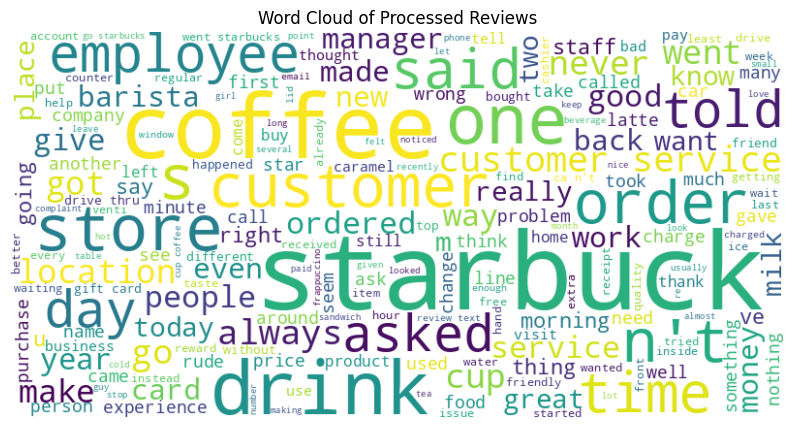

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all the processed reviews into a single string
all_words = ' '.join([text for text in df['Review_processed']])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110, background_color='white').generate(all_words)

# Display the generated image:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud of Processed Reviews')
plt.show()